# House Price Prediction Using Multiple Linear Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Data Loading 

In [2]:
df = pd.read_csv('House-Price-Prediction.csv')

In [3]:
df.head()  # Top rows

,Size,Number of Bedrooms,Age,Distance to City Center,Price
0,850,2,10,5.0,120000
1,900,2,5,4.0,130000
2,1200,3,8,3.0,150000
3,1500,3,20,2.0,175000
4,1750,4,15,2.5,180000


In [5]:
df.tail()

,Size,Number of Bedrooms,Age,Distance to City Center,Price
85,18200,5,2,3.1,1300000
86,18400,4,3,3.5,1310000
87,18600,5,4,3.8,1320000
88,18800,6,5,4.0,1340000
89,19000,6,6,3.5,1350000


In [6]:
df.sample(7)

,Size,Number of Bedrooms,Age,Distance to City Center,Price
70,15200,6,4,2.1,1080000
79,17000,6,6,2.9,1210000
12,3600,4,6,4.2,300000
50,11200,5,2,4.0,820000
48,10800,5,2,3.0,790000
47,10600,4,3,2.5,780000
25,6200,4,3,4.2,480000


In [7]:
df.shape  # show the shape of df

(90, 5)

In [8]:
df.info() # Short overview of the df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Size                     90 non-null     int64  
 1   Number of Bedrooms       90 non-null     int64  
 2   Age                      90 non-null     int64  
 3   Distance to City Center  90 non-null     float64
 4   Price                    90 non-null     int64  
dtypes: float64(1), int64(4)
memory usage: 3.6 KB


In [9]:
df.describe().T # Basic Statistics of df

,count,mean,std,min,25%,50%,75%,max
Size,90.0,10074.444444,5266.878937,850.0,5650.00,10100.0,14550.0,19000.0
Number of Bedrooms,90.0,5.044444,1.048392,2.0,4.00,5.0,6.0,7.0
Age,90.0,6.100000,3.502968,1.0,3.25,6.0,8.0,20.0
Distance to City Center,90.0,3.174444,0.744049,1.5,2.50,3.0,3.6,5.1
Price,90.0,740000.000000,357043.886768,120000.0,435000.00,740000.0,1037500.0,1350000.0


# Cleaning and Preprocessing

In [10]:
df.columns = df.columns.str.strip()
df.columns

Index(['Size', 'Number of Bedrooms', 'Age', 'Distance to City Center',
       'Price'],
      dtype='object')

In [11]:
df.dtypes

Size                         int64
Number of Bedrooms           int64
Age                          int64
Distance to City Center    float64
Price                        int64
dtype: object

In [12]:
df.isna().sum()  # sum of all of the NULL values in  a df

Size                       0
Number of Bedrooms         0
Age                        0
Distance to City Center    0
Price                      0
dtype: int64

In [16]:
df.duplicated().sum()  # show all duplicates present in a df

np.int64(0)

# Correlation and Valuaization

In [17]:
df.corr().T

,Size,Number of Bedrooms,Age,Distance to City Center,Price
Size,1.000000,0.452657,-0.368094,-0.117666,0.999904
Number of Bedrooms,0.452657,1.000000,-0.200091,-0.200184,0.449802
Age,-0.368094,-0.200091,1.000000,-0.043411,-0.366128
Distance to City Center,-0.117666,-0.200184,-0.043411,1.000000,-0.118404
Price,0.999904,0.449802,-0.366128,-0.118404,1.000000


<Axes: >

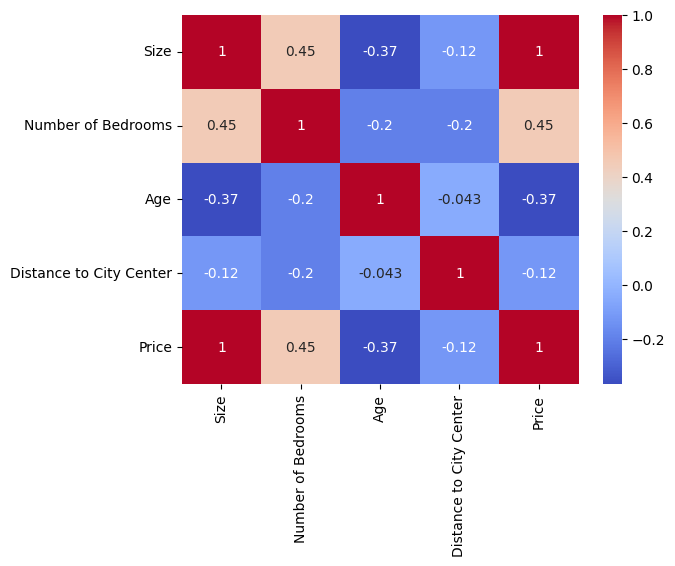

In [18]:
sns.heatmap( df.corr() , annot=True , cmap='coolwarm') 

# Divide the dataset into dependent and independent features

In [19]:
X = df.iloc[:,:-1] # independent Feature
y = df.iloc[:,-1]  # Dependent Feature

In [20]:
X

,Size,Number of Bedrooms,Age,Distance to City Center
0,850,2,10,5.0
1,900,2,5,4.0
2,1200,3,8,3.0
3,1500,3,20,2.0
4,1750,4,15,2.5
...,...,...,...,...
85,18200,5,2,3.1
86,18400,4,3,3.5
87,18600,5,4,3.8
88,18800,6,5,4.0


In [21]:
y

0      120000
1      130000
2      150000
3      175000
4      180000
       ...   
85    1300000
86    1310000
87    1320000
88    1340000
89    1350000
Name: Price, Length: 90, dtype: int64

# Divide the Dataset into Train and Test Dataset

In [22]:
from sklearn.model_selection import train_test_split

In [24]:
# Divide the Dataset into Train and Test Dataset
X_train , X_test , y_train, y_test = train_test_split(X,y , test_size=0.25 , random_state=42)

# Find MultiCollinearity b/w Independent Features

In [25]:
# A fun which check the a correaltion among the independent variables
def correlation(df , threshould):
    corr_columns = set()   # A set of columns that have high correlation with each other
    corr_matrix = df.corr()
    for i in  range(0 , len(corr_matrix.columns)):
        for j in range( i ):
            if abs(corr_matrix.iloc[i][j]) > threshould:
                column = corr_matrix.columns[i]
                corr_columns.add(column)
        
    return corr_columns



In [26]:
high_corr_columns = correlation(X_train, 0.90) # collect all the correlated columns

In [27]:
X_train= X_train.drop(columns=high_corr_columns) # drop the high correlated independent feaures


In [28]:
X_train

,Size,Number of Bedrooms,Age,Distance to City Center
30,7200,5,5,3.3
33,7800,4,8,3.6
11,3400,3,8,3.5
66,14400,5,2,2.9
67,14600,4,1,3.4
...,...,...,...,...
20,5200,5,10,3.0
60,13200,5,8,2.8
71,15400,6,5,2.5
14,4000,5,3,2.5


# StandardScaler

In [29]:
from sklearn.preprocessing import StandardScaler

In [30]:
scaler = StandardScaler() # Scale Down the independet Features

In [31]:
X_train_scaled = scaler.fit_transform( X_train )

In [32]:
X_train_scaled

array([[-0.54738399,  0.        , -0.29402994,  0.230144  ],
       [-0.43354624, -0.96465308,  0.56249206,  0.6431703 ],
       [-1.26835638, -1.92930615,  0.56249206,  0.50549487],
       [ 0.81866896,  0.        , -1.15055193, -0.32055772],
       [ 0.85661488, -0.96465308, -1.43605926,  0.36781944],
       [-0.50943807, -0.96465308, -0.00852261, -0.32055772],
       [ 1.1601822 ,  0.96465308,  0.84799939,  0.36781944],
       [-1.34424821,  0.        ,  1.13350672, -0.18288229],
       [ 0.89456079,  0.        , -1.15055193,  0.6431703 ],
       [-1.53397778, -0.96465308, -0.29402994,  0.50549487],
       [-0.092033  ,  0.        ,  0.56249206,  1.19387202],
       [ 0.09769657, -0.96465308, -0.8650446 , -0.87125944],
       [-1.0786268 ,  0.        , -1.15055193, -0.18288229],
       [ 0.02180474, -0.96465308, -0.29402994,  1.46922288],
       [-0.39560033,  0.        ,  0.84799939, -1.00893488],
       [-1.439113  , -1.92930615,  1.70452138, -0.18288229],
       [ 1.27401995,  0.

In [33]:
X_test_scaled = scaler.transform(X_test) # transform the X_test

# Model Selection and Training

In [34]:
from sklearn.linear_model import LinearRegression

In [35]:
regressor = LinearRegression()

In [36]:
regressor.fit(X_train_scaled , y_train) # Tain the model on the given data

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
regressor.intercept_ # intercept of the best fit line

np.float64(740895.5223880596)

In [38]:
regressor.coef_  # coefficient of independent feautures

array([357735.13380332,   -987.00247936,    643.55983881,   -590.04512952])

In [39]:
# predicted values
y_predicted = regressor.predict(X_test_scaled)

In [40]:
y_predicted

array([ 679409.85715389,  433638.47441542,  883369.59215589,
       1087574.46132815,  116152.9373559 ,  489962.40893019,
        666928.58286378, 1018380.49880232,  275477.30634266,
        734573.80398792, 1237115.92178677,  613566.35964926,
        896721.74670538, 1305351.05755099,  300814.19335969,
        178283.92248689,  382690.59109477,  516933.12381626,
        801771.7383078 ,  979809.9534199 , 1129070.44825922,
       1072516.37770896, 1169858.02436612])

# Visulizing Actual vs Predicted Values

Text(0.5, 1.0, 'Actual vs Predicted Values')

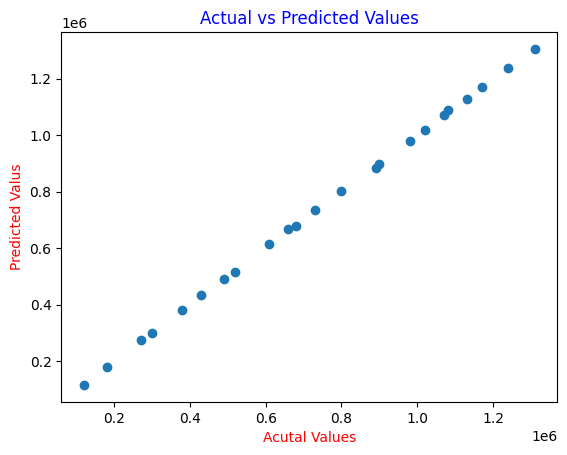

In [41]:
# visulize Actual and Predicted values

plt.scatter(y_test , y_predicted)
plt.xlabel("Acutal Values" , c = 'red')
plt.ylabel("Predicted Valus" , c = 'red')
plt.title("Actual vs Predicted Values" , c = 'blue') 

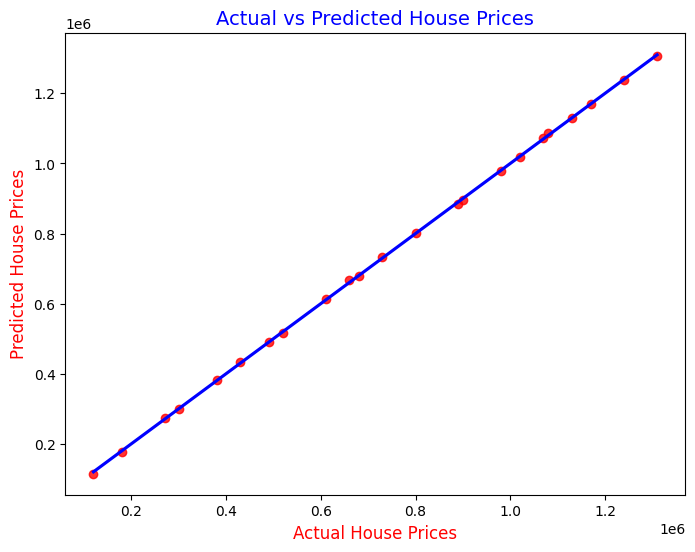

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a regression plot
plt.figure(figsize=(8, 6))
sns.regplot(x=y_test, y=y_predicted, scatter_kws={"color": "red"}, line_kws={"color": "blue"})

# Labels and Title
plt.xlabel("Actual House Prices", fontsize=12, color='red')
plt.ylabel("Predicted House Prices", fontsize=12, color='red')
plt.title("Actual vs Predicted House Prices", fontsize=14, color='blue')

# Show the plot
plt.show()


# Model Evaluation

In [43]:
from sklearn.metrics import mean_squared_error , mean_absolute_error  , r2_score

In [45]:
accuracy = r2_score(y_test, y_predicted)
print("Accuracy : ", accuracy)

Accuracy :  0.9998873902164794


In [46]:
mse = mean_squared_error(y_test, y_predicted)
print(f"Mean Squared Error : {mse}")

Mean Squared Error : 13709229.997179365


In [50]:
mae = mean_absolute_error(y_test, y_predicted)
print(f"Mean Absolute Error : {mae}")

Mean Absolute Error : 3005.756359507821


### Training vs Testing Accuracy

In [59]:
training_predictions = regressor.predict(X_train_scaled)


In [60]:
training_accuracy = r2_score(y_train, training_predictions)
print(f"Training Accuracy : {training_accuracy}")

Training Accuracy : 0.9997993018451772


In [63]:
difference = training_accuracy - accuracy
print(f"Difference b/w training and testing accuracy is : {difference}")

Difference b/w training and testing accuracy is : -8.808837130225289e-05



## 16. Underfitting vs. Overfitting

```text
Underfitting  = model too simple to capture the real pattern
                (e.g. forcing a flat/straight line onto a clearly curved trend)

Good fit      = model captures the underlying relationship well

Overfitting   = model learns the noise/quirks of the training data instead of
                the general pattern (common with very flexible models, less of a
                concern for a single straight line, but still worth knowing)
```



In [68]:
df.head()

,Size,Number of Bedrooms,Age,Distance to City Center,Price
0,850,2,10,5.0,120000
1,900,2,5,4.0,130000
2,1200,3,8,3.0,150000
3,1500,3,20,2.0,175000
4,1750,4,15,2.5,180000


In [70]:
point = scaler.transform([[1500, 3, 5, 4.3]])

In [71]:
regressor.predict(point)

array([158968.16816966])

# Model Save

In [73]:
import pickle

In [74]:
# store the scaler model
with open('Scaler.pkl' , 'wb') as f:
    pickle.dump(scaler , f)  

In [75]:
# Store the Regressor Model
with open("Regsssor.pkl" , 'wb') as f:
    pickle.dump(regressor , f)

# Load the Model

In [76]:
with open("Scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

In [89]:
with open("Regsssor.pkl", "rb") as f:
    regressor = pickle.load(f)

In [84]:
df.sample(3)

,Size,Number of Bedrooms,Age,Distance to City Center,Price
84,18000,6,1,2.5,1280000
35,8200,6,10,2.1,610000
38,8800,6,7,2.4,650000


In [85]:
points =[[1800, 4, 15.5, 2.5],
         [10220, 3, 4, 5]
        ]

In [87]:
points = scaler.transform(points)

In [90]:
predictionss = regressor.predict(points)

In [91]:
predictionss

array([181769.43978428, 750067.78102054])

In [94]:
print(predictionss[0])

181769.4397842777
